In [ ]:
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from scipy.stats import mannwhitneyu

In [ ]:
df = pd.read_csv('btc_historical_data.csv')
df = df.rename(columns={'time': 'date'})
df = df.drop(['Unnamed: 0', 'volumeto'], axis=1)
df

,date,open,high,low,close,volume
0,2021-01-01 00:00:00,28972.40,29074.84,28748.21,29048.90,2563.47
1,2021-01-01 01:00:00,29048.90,29522.86,29015.06,29465.74,5281.86
2,2021-01-01 02:00:00,29465.74,29509.78,29175.40,29237.60,2526.00
3,2021-01-01 03:00:00,29237.60,29393.34,29212.96,29341.42,1316.75
4,2021-01-01 04:00:00,29341.42,29436.68,29125.09,29272.63,1930.17
...,...,...,...,...,...,...
28009,2023-12-30 20:00:00,42356.02,42395.26,42206.17,42283.05,774.42
28010,2023-12-30 21:00:00,42283.05,42322.06,42226.57,42297.51,629.04
28011,2023-12-30 22:00:00,42297.51,42304.46,42079.26,42134.31,671.46
28012,2023-12-30 23:00:00,42134.31,42292.08,42104.22,42146.03,752.63


*Doing some exploratory data analysis*

In [ ]:
df["target"] = df['close'].shift(-1)
df = df.dropna()
df.shape

(28013, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28013 entries, 0 to 28012
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    28013 non-null  object 
 1   open    28013 non-null  float64
 2   high    28013 non-null  float64
 3   low     28013 non-null  float64
 4   close   28013 non-null  float64
 5   volume  28013 non-null  float64
 6   target  28013 non-null  float64
dtypes: float64(6), object(1)
memory usage: 1.7+ MB


In [ ]:
df.head()

,date,open,high,low,close,volume,target
0,2021-01-01 00:00:00,28972.40,29074.84,28748.21,29048.90,2563.47,29465.74
1,2021-01-01 01:00:00,29048.90,29522.86,29015.06,29465.74,5281.86,29237.60
2,2021-01-01 02:00:00,29465.74,29509.78,29175.40,29237.60,2526.00,29341.42
3,2021-01-01 03:00:00,29237.60,29393.34,29212.96,29341.42,1316.75,29272.63
4,2021-01-01 04:00:00,29341.42,29436.68,29125.09,29272.63,1930.17,29227.43


*Now we are finding the technical indicators using this ohclv data.*

*Technical indicators*

---

1.   *MACD (EMA(12) - EMA(26))*
2.   *RSI (14-period)*
3.   *EMA (EMA for 7-day and 21-day)*
4.   *ATR - Average True Range*
5.   *BB (Upper, Middle, Lower and Width)*





In [ ]:
def calculate_technical_indicators(df):
    """
    df: pandas DataFrame with columns ['Open', 'High', 'Low', 'Close', 'Volume']
    Returns:
        DataFrame  prices, volume, timestamp-features and technical indicators suitable for TFT
    """

    df = df.copy()

    # Ensure numeric
    for col in ['open', 'high', 'low', 'close', 'volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    close = df['close']

    # EMA
    df['EMA_7']  = close.ewm(span=7, adjust=False).mean()
    df['EMA_21'] = close.ewm(span=21, adjust=False).mean()

    # RSI
    delta = close.diff()
    U_t = delta.clip(lower=0)
    D_t = -delta.clip(upper=0)
    avg_gain = U_t.rolling(window=14, min_periods=14).mean()
    avg_loss = D_t.rolling(window=14, min_periods=14).mean()
    RS = avg_gain / (avg_loss + 1e-9)
    df['RSI_14'] = 100 - (100 / (1 + RS))

    # MACD
    EMA_12 = close.ewm(span=12, adjust=False).mean()
    EMA_26 = close.ewm(span=26, adjust=False).mean()
    df['MACD'] = EMA_12 - EMA_26

    # Bollinger Bands
    bb_mid = close.rolling(window=20).mean()
    bb_std = close.rolling(window=20).std()
    df['BB_Width'] = (2 * bb_std) / bb_mid

    # ATR
    high_low = df['high'] - df['low']
    high_close = (df['high'] - close.shift()).abs()
    low_close = (df['low'] - close.shift()).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['ATR_14'] = true_range.rolling(window=14).mean()

    return df


In [ ]:
# now calculting the necessary technical indicators -> technical analysis
df = calculate_technical_indicators(df)
df = df.dropna()

In [ ]:
df.head()

,date,open,high,low,close,volume,target,EMA_7,EMA_21,RSI_14,MACD,BB_Width,ATR_14
19,2021-01-01 19:00:00,29129.74,29190.61,29024.48,29103.64,1817.85,29299.90,29211.135875,29220.690707,45.736290,22.628389,0.008915,290.737857
20,2021-01-01 20:00:00,29103.64,29345.76,28970.82,29299.90,2400.76,29242.18,29233.326907,29227.891552,52.574963,26.386481,0.008268,306.687857
21,2021-01-01 21:00:00,29299.90,29360.24,29238.47,29242.18,1343.70,29338.37,29235.540180,29229.190502,52.815777,24.425709,0.007654,292.283571
22,2021-01-01 22:00:00,29242.18,29393.93,29195.42,29338.37,1076.32,29388.94,29261.247635,29239.115911,58.587969,30.284413,0.007738,285.577143
23,2021-01-01 23:00:00,29338.37,29399.14,29304.25,29388.94,939.13,29251.47,29293.170726,29252.736283,54.285347,38.563518,0.007887,269.395000


*No null values, but date is not a datetime type...*

In [ ]:
def date_preprocess(data):
  # Convert to datetime type, invalid ones → NaT (Not a Time)
  data['date'] = pd.to_datetime(data['date'], errors='coerce')
  # Remove rows with invalid date, ie, removing NaT values
  data = data.dropna(subset=['date'])
  data = data.sort_values("date")
  return data

In [ ]:
df = date_preprocess(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27994 entries, 19 to 28012
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      27994 non-null  datetime64[ns]
 1   open      27994 non-null  float64       
 2   high      27994 non-null  float64       
 3   low       27994 non-null  float64       
 4   close     27994 non-null  float64       
 5   volume    27994 non-null  float64       
 6   target    27994 non-null  float64       
 7   EMA_7     27994 non-null  float64       
 8   EMA_21    27994 non-null  float64       
 9   RSI_14    27994 non-null  float64       
 10  MACD      27994 non-null  float64       
 11  BB_Width  27994 non-null  float64       
 12  ATR_14    27994 non-null  float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 3.0 MB


In [ ]:
df

,date,open,high,low,close,volume,target,EMA_7,EMA_21,RSI_14,MACD,BB_Width,ATR_14
19,2021-01-01 19:00:00,29129.74,29190.61,29024.48,29103.64,1817.85,29299.90,29211.135875,29220.690707,45.736290,22.628389,0.008915,290.737857
20,2021-01-01 20:00:00,29103.64,29345.76,28970.82,29299.90,2400.76,29242.18,29233.326907,29227.891552,52.574963,26.386481,0.008268,306.687857
21,2021-01-01 21:00:00,29299.90,29360.24,29238.47,29242.18,1343.70,29338.37,29235.540180,29229.190502,52.815777,24.425709,0.007654,292.283571
22,2021-01-01 22:00:00,29242.18,29393.93,29195.42,29338.37,1076.32,29388.94,29261.247635,29239.115911,58.587969,30.284413,0.007738,285.577143
23,2021-01-01 23:00:00,29338.37,29399.14,29304.25,29388.94,939.13,29251.47,29293.170726,29252.736283,54.285347,38.563518,0.007887,269.395000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28008,2023-12-30 19:00:00,42404.80,42442.93,42334.83,42356.02,641.04,42283.05,42301.477474,42175.471198,58.415593,32.504156,0.011829,207.599286
28009,2023-12-30 20:00:00,42356.02,42395.26,42206.17,42283.05,774.42,42297.51,42296.870605,42185.251089,58.041596,35.362955,0.012044,211.556429
28010,2023-12-30 21:00:00,42283.05,42322.06,42226.57,42297.51,629.04,42134.31,42297.030454,42195.456444,62.019234,38.353262,0.012241,204.562857
28011,2023-12-30 22:00:00,42297.51,42304.46,42079.26,42134.31,671.46,42146.03,42256.350340,42189.897677,71.961946,27.240217,0.012083,190.277143


*Now we are merging with our sentiment dataset....*

In [ ]:
sentiment_df = pd.read_csv('final_btc_hourly_sentiments.csv')
sentiment_df

,date,vader_score,roberta_score,tweet_count
0,2021-07-17 05:00:00,0.176910,0.100000,10
1,2021-07-17 06:00:00,0.037589,0.000000,18
2,2021-07-17 07:00:00,0.295887,0.133333,15
3,2021-07-17 08:00:00,0.197756,0.074074,27
4,2021-07-17 09:00:00,0.235200,-0.008753,457
...,...,...,...,...
14318,2023-03-05 19:00:00,0.112897,-0.044223,701
14319,2023-03-05 20:00:00,0.120995,0.010622,659
14320,2023-03-05 21:00:00,0.108932,-0.034826,603
14321,2023-03-05 22:00:00,0.105168,-0.030534,524


In [ ]:
sentiment_df.isna().sum()

,0
date,0
vader_score,0
roberta_score,0
tweet_count,0


In [ ]:
# converting the date (object datatype) part of sentiment_df to datetime type
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14323 entries, 0 to 14322
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           14323 non-null  datetime64[ns]
 1   vader_score    14323 non-null  float64       
 2   roberta_score  14323 non-null  float64       
 3   tweet_count    14323 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 447.7 KB


In [ ]:
# finally merging based on the date column and dropping all the null value rows
final_df = pd.merge(df, sentiment_df, on='date', how='inner')
final_df = final_df.dropna()
final_df.shape

(14330, 16)

In [ ]:
# final crypto data for passing as input to our models
final_df.head()

,date,open,high,low,close,volume,target,EMA_7,EMA_21,RSI_14,MACD,BB_Width,ATR_14,vader_score,roberta_score,tweet_count
0,2021-07-17 05:00:00,31410.68,31556.38,31406.10,31500.51,1108.13,31613.56,31480.865202,31624.380564,27.914743,-113.205712,0.018995,243.419286,0.176910,0.100000,10
1,2021-07-17 06:00:00,31500.51,31614.95,31475.15,31613.56,813.76,31545.10,31514.038902,31623.396876,34.736696,-99.528202,0.018335,223.873571,0.037589,0.000000,18
2,2021-07-17 07:00:00,31613.56,31615.69,31495.93,31545.10,940.96,31730.45,31521.804176,31616.278979,33.092090,-93.139176,0.016328,219.865714,0.295887,0.133333,15
3,2021-07-17 08:00:00,31545.10,31966.25,31383.23,31730.45,1320.14,31641.49,31573.965632,31626.658162,42.449934,-72.286359,0.016332,251.252143,0.197756,0.074074,27
4,2021-07-17 09:00:00,31730.45,31809.73,31632.94,31641.49,860.88,31323.53,31590.846724,31628.006511,41.793635,-62.221430,0.016317,249.166429,0.235200,-0.008753,457


In [ ]:
# creating a missing masks to handle sparse features (sentiments) as per the TFT model
final_df['sentiment_missing'] = np.where(final_df['tweet_count'] > 0, 0, 1)

final_df[['vader_score', 'roberta_score', 'sentiment_missing', 'tweet_count']].sample(10)

,vader_score,roberta_score,sentiment_missing,tweet_count
5649,0.249077,0.015152,0,132
11811,0.000000,0.000000,1,0
1161,0.000000,0.000000,1,0
6436,0.000000,0.000000,1,0
2767,0.000000,0.000000,1,0
13102,0.000000,0.000000,1,0
2203,0.000000,0.000000,1,0
6098,0.000000,0.000000,1,0
4259,0.000000,0.000000,1,0
14229,0.157976,0.030588,0,850


*Now we are calculating and merging the Fear and Greed Index (FGI)...*

***The Crypto Fear and Greed Index** is a daily sentiment score ranging from 0 (extreme
fear) to 100 (extreme greed). It is published by Alternative.me and incorporates multiple
components, including price momentum, volatility, social media activity, Google search
volume, and market dominance. As a composite index, it is designed to represent shortterm crowd sentiment, making it especially useful for capturing rapid shifts in market
mood that may not be reflected in transactional or price data alone*

In [ ]:
import requests

def add_fgi_to_hourly(hourly_df):
    """
    Fetch daily Fear & Greed Index (FGI) and merge into an hourly dataset.
    Only the scaled FGI value is added.

    Arguments:
        hourly_df: DataFrame with 'date' column (hourly datetime)
    Returns:
        hourly_df with new column 'FGI'
    """
    # Fetch FGI data
    url = "https://api.alternative.me/fng/?limit=0&format=json"
    response = requests.get(url)
    data = response.json()["data"]

    fgi_df = pd.DataFrame(data)
    fgi_df["date"] = pd.to_datetime(fgi_df["timestamp"], unit="s")
    fgi_df["FGI"] = fgi_df["value"].astype(float) / 100.0  # scale 0-1

    # Align FGI to hourly data
    hourly_df = hourly_df.copy()
    hourly_df["date_only"] = hourly_df["date"].dt.floor("D")
    fgi_df["date_only"] = fgi_df["date"].dt.floor("D")

    # Merge and forward-fill missing days
    hourly_df = hourly_df.merge(fgi_df[["date_only", "FGI"]], on="date_only", how="left")
    hourly_df["FGI"] = hourly_df["FGI"].ffill()

    # Drop helper column
    hourly_df.drop(columns=["date_only"], inplace=True)

    return hourly_df


In [ ]:
# Assume df contains price + indicators
final_df = add_fgi_to_hourly(final_df)
final_df

/tmp/ipython-input-757190075.py:19: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  fgi_df["date"] = pd.to_datetime(fgi_df["timestamp"], unit="s")


,date,open,high,low,close,volume,target,EMA_7,EMA_21,RSI_14,MACD,BB_Width,ATR_14,vader_score,roberta_score,tweet_count,sentiment_missing,FGI
0,2021-07-17 05:00:00,31410.68,31556.38,31406.10,31500.51,1108.13,31613.56,31480.865202,31624.380564,27.914743,-113.205712,0.018995,243.419286,0.176910,0.100000,10,0,0.15
1,2021-07-17 06:00:00,31500.51,31614.95,31475.15,31613.56,813.76,31545.10,31514.038902,31623.396876,34.736696,-99.528202,0.018335,223.873571,0.037589,0.000000,18,0,0.15
2,2021-07-17 07:00:00,31613.56,31615.69,31495.93,31545.10,940.96,31730.45,31521.804176,31616.278979,33.092090,-93.139176,0.016328,219.865714,0.295887,0.133333,15,0,0.15
3,2021-07-17 08:00:00,31545.10,31966.25,31383.23,31730.45,1320.14,31641.49,31573.965632,31626.658162,42.449934,-72.286359,0.016332,251.252143,0.197756,0.074074,27,0,0.15
4,2021-07-17 09:00:00,31730.45,31809.73,31632.94,31641.49,860.88,31323.53,31590.846724,31628.006511,41.793635,-62.221430,0.016317,249.166429,0.235200,-0.008753,457,0,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14325,2023-03-05 19:00:00,22435.69,22451.61,22387.08,22409.69,827.71,22414.95,22428.894031,22412.630587,47.723642,13.093551,0.004444,45.012143,0.112897,-0.044223,701,0,0.47
14326,2023-03-05 20:00:00,22409.69,22424.07,22403.98,22414.95,395.82,22488.75,22425.408023,22412.841442,48.290741,11.408082,0.004368,45.185000,0.120995,0.010622,659,0,0.47
14327,2023-03-05 21:00:00,22414.95,22536.32,22358.69,22488.75,2366.50,22436.93,22441.243517,22419.742220,64.931224,15.844731,0.003122,54.404286,0.108932,-0.034826,603,0,0.47
14328,2023-03-05 22:00:00,22488.75,22490.74,22397.85,22436.93,939.00,22434.09,22440.165138,22421.304746,61.938094,15.006382,0.002953,56.584286,0.105168,-0.030534,524,0,0.47


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14330 entries, 0 to 14329
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               14330 non-null  datetime64[ns]
 1   open               14330 non-null  float64       
 2   high               14330 non-null  float64       
 3   low                14330 non-null  float64       
 4   close              14330 non-null  float64       
 5   volume             14330 non-null  float64       
 6   target             14330 non-null  float64       
 7   EMA_7              14330 non-null  float64       
 8   EMA_21             14330 non-null  float64       
 9   RSI_14             14330 non-null  float64       
 10  MACD               14330 non-null  float64       
 11  BB_Width           14330 non-null  float64       
 12  ATR_14             14330 non-null  float64       
 13  vader_score        14330 non-null  float64       
 14  robert

In [ ]:
final_df = final_df.reset_index(drop=True)
final_df[:60]

,date,open,high,low,close,volume,asset,target,EMA_7,EMA_21,RSI_14,MACD,BB_Width,ATR_14,vader_score,roberta_score,tweet_count,sentiment_missing,FGI
0,2021-07-17 05:00:00,31410.68,31556.38,31406.10,31500.51,1108.13,BTC,31613.56,31480.865202,31624.380564,27.914743,-113.205712,0.018995,243.419286,0.176910,0.100000,10,0,0.15
1,2021-07-17 06:00:00,31500.51,31614.95,31475.15,31613.56,813.76,BTC,31545.10,31514.038902,31623.396876,34.736696,-99.528202,0.018335,223.873571,0.037589,0.000000,18,0,0.15
2,2021-07-17 07:00:00,31613.56,31615.69,31495.93,31545.10,940.96,BTC,31730.45,31521.804176,31616.278979,33.092090,-93.139176,0.016328,219.865714,0.295887,0.133333,15,0,0.15
3,2021-07-17 08:00:00,31545.10,31966.25,31383.23,31730.45,1320.14,BTC,31641.49,31573.965632,31626.658162,42.449934,-72.286359,0.016332,251.252143,0.197756,0.074074,27,0,0.15
4,2021-07-17 09:00:00,31730.45,31809.73,31632.94,31641.49,860.88,BTC,31323.53,31590.846724,31628.006511,41.793635,-62.221430,0.016317,249.166429,0.235200,-0.008753,457,0,0.15
5,2021-07-17 10:00:00,31641.49,31641.79,31299.82,31323.53,1452.47,BTC,31423.74,31524.017543,31600.326828,36.532795,-78.991056,0.016886,264.151429,0.242448,0.038328,574,0,0.15
6,2021-07-17 11:00:00,31323.53,31496.61,31294.20,31423.74,1404.08,BTC,31538.44,31498.948157,31584.273480,41.743411,-83.235509,0.015561,265.933571,0.169314,-0.036822,516,0,0.15
7,2021-07-17 12:00:00,31423.74,31597.77,31389.30,31538.44,713.45,BTC,31651.14,31508.821118,31580.106800,48.457625,-76.462524,0.014109,259.047143,0.161570,-0.025253,594,0,0.15
8,2021-07-17 13:00:00,31538.44,31769.44,31383.08,31651.14,1260.10,BTC,31665.90,31544.400838,31586.564364,56.844330,-61.294374,0.012238,267.070000,0.200301,0.020767,626,0,0.15
9,2021-07-17 14:00:00,31651.14,31762.73,31630.93,31665.90,549.85,BTC,31777.20,31574.775629,31593.776694,50.988997,-47.534548,0.010782,245.055000,0.172180,-0.069465,691,0,0.15


In [ ]:
df1 = final_df.copy()
df1

,date,open,high,low,close,volume,target,EMA_7,EMA_21,RSI_14,MACD,BB_Width,ATR_14,vader_score,roberta_score,tweet_count,sentiment_missing,FGI
0,2021-07-17 05:00:00,31410.68,31556.38,31406.10,31500.51,1108.13,31613.56,31480.865202,31624.380564,27.914743,-113.205712,0.018995,243.419286,0.176910,0.100000,10,0,0.15
1,2021-07-17 06:00:00,31500.51,31614.95,31475.15,31613.56,813.76,31545.10,31514.038902,31623.396876,34.736696,-99.528202,0.018335,223.873571,0.037589,0.000000,18,0,0.15
2,2021-07-17 07:00:00,31613.56,31615.69,31495.93,31545.10,940.96,31730.45,31521.804176,31616.278979,33.092090,-93.139176,0.016328,219.865714,0.295887,0.133333,15,0,0.15
3,2021-07-17 08:00:00,31545.10,31966.25,31383.23,31730.45,1320.14,31641.49,31573.965632,31626.658162,42.449934,-72.286359,0.016332,251.252143,0.197756,0.074074,27,0,0.15
4,2021-07-17 09:00:00,31730.45,31809.73,31632.94,31641.49,860.88,31323.53,31590.846724,31628.006511,41.793635,-62.221430,0.016317,249.166429,0.235200,-0.008753,457,0,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14325,2023-03-05 19:00:00,22435.69,22451.61,22387.08,22409.69,827.71,22414.95,22428.894031,22412.630587,47.723642,13.093551,0.004444,45.012143,0.112897,-0.044223,701,0,0.47
14326,2023-03-05 20:00:00,22409.69,22424.07,22403.98,22414.95,395.82,22488.75,22425.408023,22412.841442,48.290741,11.408082,0.004368,45.185000,0.120995,0.010622,659,0,0.47
14327,2023-03-05 21:00:00,22414.95,22536.32,22358.69,22488.75,2366.50,22436.93,22441.243517,22419.742220,64.931224,15.844731,0.003122,54.404286,0.108932,-0.034826,603,0,0.47
14328,2023-03-05 22:00:00,22488.75,22490.74,22397.85,22436.93,939.00,22434.09,22440.165138,22421.304746,61.938094,15.006382,0.002953,56.584286,0.105168,-0.030534,524,0,0.47


In [ ]:
df1['date'] = pd.to_datetime(df1['date'])
df1 = df1.set_index('date')
df1.head()

,open,high,low,close,volume,target,EMA_7,EMA_21,RSI_14,MACD,BB_Width,ATR_14,vader_score,roberta_score,tweet_count,sentiment_missing,FGI
date,,,,,,,,,,,,,,,,,
2021-07-17 05:00:00,31410.68,31556.38,31406.10,31500.51,1108.13,31613.56,31480.865202,31624.380564,27.914743,-113.205712,0.018995,243.419286,0.176910,0.100000,10,0,0.15
2021-07-17 06:00:00,31500.51,31614.95,31475.15,31613.56,813.76,31545.10,31514.038902,31623.396876,34.736696,-99.528202,0.018335,223.873571,0.037589,0.000000,18,0,0.15
2021-07-17 07:00:00,31613.56,31615.69,31495.93,31545.10,940.96,31730.45,31521.804176,31616.278979,33.092090,-93.139176,0.016328,219.865714,0.295887,0.133333,15,0,0.15
2021-07-17 08:00:00,31545.10,31966.25,31383.23,31730.45,1320.14,31641.49,31573.965632,31626.658162,42.449934,-72.286359,0.016332,251.252143,0.197756,0.074074,27,0,0.15
2021-07-17 09:00:00,31730.45,31809.73,31632.94,31641.49,860.88,31323.53,31590.846724,31628.006511,41.793635,-62.221430,0.016317,249.166429,0.235200,-0.008753,457,0,0.15


In [ ]:
df_4h = df1.resample('4H').agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum',
    'tweet_count': 'sum',
    'vader_score': 'mean',
    'roberta_score': 'mean',
    'sentiment_missing': 'max',
    'FGI': 'last'
})

/tmp/ipython-input-3222777316.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_4h = df1.resample('4H').agg({


In [ ]:
df_4h = calculate_technical_indicators(df_4h)
df_4h = df_4h.dropna()
df_4h

,open,high,low,close,volume,tweet_count,vader_score,roberta_score,sentiment_missing,FGI,EMA_7,EMA_21,RSI_14,MACD,BB_Width,ATR_14
date,,,,,,,,,,,,,,,,
2021-07-20 08:00:00,29847.06,29903.50,29320.09,29708.89,7890.90,2269,0.088857,-0.072383,1,0.19,30312.752148,30983.498948,21.681540,-415.769719,0.047960,537.750000
2021-07-20 12:00:00,29708.89,29997.97,29334.84,29912.79,7666.19,0,0.000000,0.000000,1,0.19,30212.761611,30886.161771,27.970022,-444.980228,0.051373,550.867857
2021-07-20 16:00:00,29912.79,29990.75,29626.18,29799.80,3743.39,0,0.000000,0.000000,1,0.19,30109.521208,30787.401610,25.464880,-471.808403,0.054821,558.448571
2021-07-20 20:00:00,29799.80,29995.10,29509.49,29795.55,4179.68,0,0.000000,0.000000,1,0.19,30031.028406,30697.233281,28.166677,-487.789925,0.056807,541.983571
2021-07-21 00:00:00,29795.55,29915.85,29513.88,29856.33,3353.77,0,0.000000,0.000000,1,0.10,29987.353805,30620.787529,24.081505,-489.903654,0.057492,540.095714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-05 04:00:00,22391.10,22468.73,22378.32,22381.72,2242.35,0,0.000000,0.000000,1,0.47,22375.653381,22644.867970,13.440255,-274.020114,0.045095,239.219286
2023-03-05 08:00:00,22381.72,22445.78,22331.28,22402.28,2152.65,0,0.000000,0.000000,1,0.47,22382.310036,22622.814518,57.383845,-258.314816,0.042074,151.517857
2023-03-05 12:00:00,22402.28,22491.26,22400.29,22445.80,2399.86,504,0.058954,0.020132,1,0.47,22398.182527,22606.722289,58.909447,-239.594657,0.039071,149.230714


In [ ]:
train_size = int(len(df_4h) * 0.8)

train_df = df_4h.iloc[:train_size].copy()
val_df   = df_4h.iloc[train_size:].copy()

print(len(train_df), len(val_df))

2849 713


In [ ]:
train_df.to_csv('train.csv')
val_df.to_csv('valid.csv')

# Hypothesis Generation and proof

# *1. if EMA_7 > EMA_21, next hour return is more likely +ve (bullish) reverse result*

In [ ]:
df1['EMA_diff'] = df1['EMA_7'] - df1['EMA_21']
df1[['EMA_7', 'EMA_21', 'EMA_diff']].head()

,EMA_7,EMA_21,EMA_diff
0,31480.865202,31624.380564,-143.515362
1,31514.038902,31623.396876,-109.357975
2,31521.804176,31616.278979,-94.474802
3,31573.965632,31626.658162,-52.692530
4,31590.846724,31628.006511,-37.159787


In [ ]:
df1['Up'] = (df1['target'] > df1['close']).astype(int)

# 3. Conditional probabilities
p_pos = df1[df1['EMA_diff'] > 0]['Up'].mean()
p_neg = df1[df1['EMA_diff'] < 0]['Up'].mean()

print("P(target > close | EMA_diff > 0):", p_pos)
print("P(target > close | EMA_diff < 0):", p_neg)

# 4. Check inequality
print("Condition satisfied:", p_pos > p_neg)

P(target > close | EMA_diff > 0): 0.48110014104372356
P(target > close | EMA_diff < 0): 0.5214088397790055
Condition satisfied: False


In [ ]:
df1['EMA_reversion_signal'] = -df1['EMA_diff']

# 3. Conditional probabilities
p_pos = df1[df1['EMA_reversion_signal'] > 0]['Up'].mean()
p_neg = df1[df1['EMA_reversion_signal'] < 0]['Up'].mean()

print("P(target > close | EMA_reversion_signal > 0):", p_pos)
print("P(target > close | EMA_reversion_signal < 0):", p_neg)

# 4. Check inequality
print("Condition satisfied:", p_pos > p_neg)

P(target > close | EMA_reversion_signal > 0): 0.5214088397790055
P(target > close | EMA_reversion_signal < 0): 0.48110014104372356
Condition satisfied: True


*When EMA_7 < EMA_21 → probability of price going up ≈ 52.14%*

*When EMA_7 > EMA_21 → probability of price going up ≈ 48.11%*

***When the short-term EMA is below the long-term EMA, the probability of price increasing in the next period is higher than when it is above. Keeping only the EMA REVERSION SIGNAL***

/tmp/ipython-input-4227183220.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(prob_data.keys()), y=list(prob_data.values()), palette="viridis")


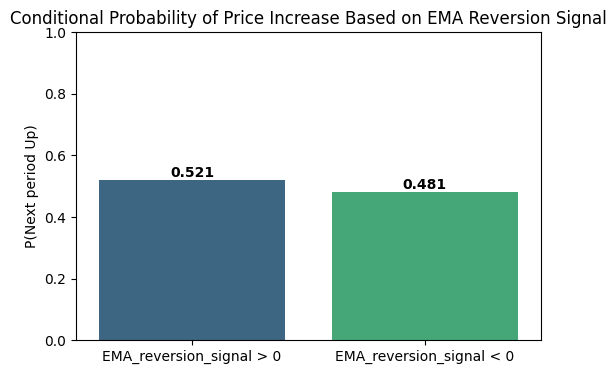

In [ ]:
# Prepare data for plotting
prob_data = {
    'EMA_reversion_signal > 0': p_pos,
    'EMA_reversion_signal < 0': p_neg
}

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=list(prob_data.keys()), y=list(prob_data.values()), palette="viridis")
plt.ylim(0, 1)
plt.ylabel("P(Next period Up)")
plt.title("Conditional Probability of Price Increase Based on EMA Reversion Signal")
for i, v in enumerate(prob_data.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

# *2. RSI Extreme Zones Predict Mean Reversion*

*   *RSI > 70 → next return negative*
*   *RSI < 30 → next return positive*

*Crypto often exhibits short-term mean reversion at extremes.*

In [ ]:
# Compute next return using existing target
df1['next_return'] = (df1['target'] - df1['close']) / df1['close']
df1 = df1.dropna(subset=['next_return'])
df1[['target', 'close', 'next_return']].head()

,target,close,next_return
0,31613.56,31500.51,0.003589
1,31545.10,31613.56,-0.002166
2,31730.45,31545.10,0.005876
3,31641.49,31730.45,-0.002804
4,31323.53,31641.49,-0.010049


In [ ]:
# RSI extreme subsets
rsi_high = df1[df1['RSI_14'] > 70]
rsi_low  = df1[df1['RSI_14'] < 30]

# Conditional expectations
mean_high = rsi_high['next_return'].mean()
mean_low  = rsi_low['next_return'].mean()

print("E(return | RSI > 70) =", mean_high)
print("E(return | RSI < 30) =", mean_low)

# Statistical test (mean ≠ 0)
t_high, p_high = stats.ttest_1samp(rsi_high['next_return'], 0)
t_low, p_low   = stats.ttest_1samp(rsi_low['next_return'], 0)

print("\nRSI > 70: t-stat =", t_high, "p-value =", p_high)
print("RSI < 30: t-stat =", t_low, "p-value =", p_low)

# Hypothesis check
print("\nHypothesis Results:")

if mean_high < 0:
    print("✔ RSI > 70 → Negative next return (mean reversion confirmed)")
else:
    print("✘ RSI > 70 condition not satisfied")

if mean_low > 0:
    print("✔ RSI < 30 → Positive next return (mean reversion confirmed)")
else:
    print("✘ RSI < 30 condition not satisfied")

E(return | RSI > 70) = 9.655153614842392e-05
E(return | RSI < 30) = -4.439310997828804e-05

RSI > 70: t-stat = 0.5988235862843817 p-value = 0.5493672030206632
RSI < 30: t-stat = -0.2363394666221692 p-value = 0.8131973720219294

Hypothesis Results:
✘ RSI > 70 condition not satisfied
✘ RSI < 30 condition not satisfied


***Hypothesis 2 is rejected. RSI extreme zones do not provide statistically significant evidence of mean reversion in this dataset. But keeping RSI is reasonable***

# *3. Volatility Predicts Larger Future Moves (But Not Direction)*

* *High ATR → larger |return|*

* *Low ATR → smaller |return|*

*This does NOT imply:*

* *High ATR → bullish*

* *Low ATR → bearish*

In [ ]:
df1['high_atr'] = df1['ATR_14'] > df1['ATR_14'].quantile(0.7)
df1['abs_next_return'] = df1['next_return'].abs()

high = df1[df1['high_atr'] == True]['abs_next_return']
low  = df1[df1['high_atr'] == False]['abs_next_return']

print(f'high ATR = {high.mean()}\nlow ATR= {low.mean()}')

high ATR = 0.005641705247474396
low ATR= 0.003664019947299725




*   *High volatility regime → average move ≈ 0.56%*

*   *Low volatility regime → average move ≈ 0.37%*



In [ ]:
ttest_ind(high, low, equal_var=False)

TtestResult(statistic=np.float64(19.005452319044732), pvalue=np.float64(2.241656133990162e-78), df=np.float64(6343.345464957647))

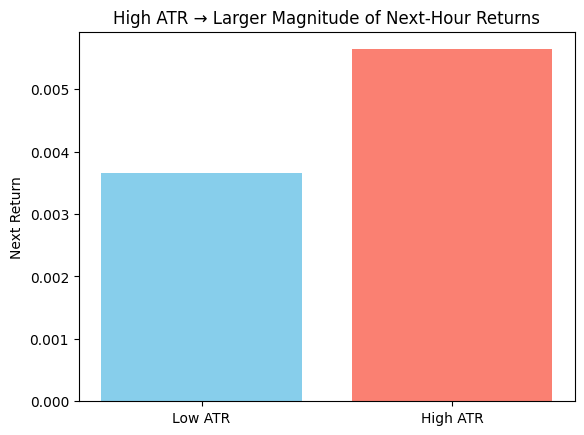

In [ ]:
# Calculate means
high_mean = high.mean()
low_mean = low.mean()

# Simple bar plot
plt.bar(['Low ATR', 'High ATR'], [low_mean, high_mean], color=['skyblue', 'salmon'])
plt.ylabel('Next Return')
plt.title('High ATR → Larger Magnitude of Next-Hour Returns')
plt.show()

***High volatility (measured by ATR_14) leads to larger magnitude of next-hour returns, but does not necessarily predict direction. so keep ATR***

# *4. Sentiment Presence ≠ Sentiment Value*

*When sentiment_missing = 0:*

* *Likely high tweet activity*

* *Likely during major events*

*The presence of sentiment itself signals volatility*.

In [ ]:
sentiment_available = df1[df1['sentiment_missing'] == 0]['abs_next_return']
sentiment_missing   = df1[df1['sentiment_missing'] == 1]['abs_next_return']

print("Mean |return| when sentiment available:",
      sentiment_available.mean())

print("Mean |return| when sentiment missing:",
      sentiment_missing.mean())

# Welch’s t-test (robust to unequal variance)
t_stat, p_value = ttest_ind(
    sentiment_available,
    sentiment_missing,
    equal_var=False
)

print("\nT-test Results")
print("t-statistic:", t_stat)
print("p-value:", p_value)

Mean |return| when sentiment available: 0.004835549766052256
Mean |return| when sentiment missing: 0.0040898736323883925

T-test Results
t-statistic: 6.645577940693997
p-value: 3.3686595885973684e-11


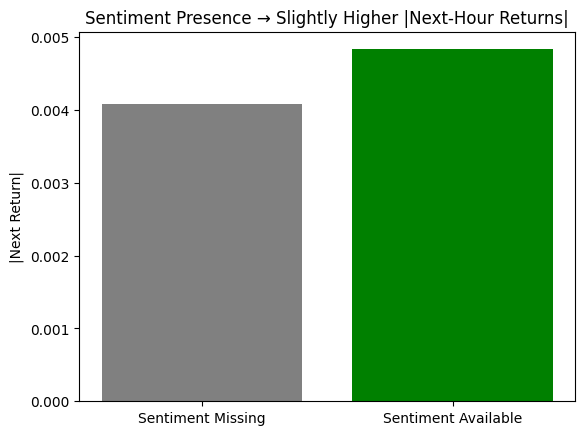

In [ ]:
mean_available = sentiment_available.mean()
mean_missing = sentiment_missing.mean()

# Simple bar plot
plt.bar(['Sentiment Missing', 'Sentiment Available'], [mean_missing, mean_available], color=['gray', 'green'])
plt.ylabel('|Next Return|')
plt.title('Sentiment Presence → Slightly Higher |Next-Hour Returns|')
plt.show()

In [ ]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(
        ((nx - 1)*np.var(x, ddof=1) +
         (ny - 1)*np.var(y, ddof=1)) /
        (nx + ny - 2)
    )
    return (np.mean(x) - np.mean(y)) / pooled_std

print("Cohen's d:", cohens_d(
    sentiment_available,
    sentiment_missing
))

Cohen's d: 0.1456021612399691


***The presence of sentiment data is associated with statistically significant increases in next-hour return magnitude, although the effect size is small. Sentiment presence acts as a mild volatility amplifier***

# *5. Tweet Count Drives Short-Term Momentum*

*If tweet_count spikes:*

*`return(t+1) ∝ tweet_count(t)`*

*But effect likely nonlinear:*

*   *Small spikes → noise*
*   *Large spikes → event-driven movement*

In [ ]:
corr, p_value = pearsonr(df1['tweet_count'], df1['next_return'])
print("Correlation:", corr)
print("p-value:", p_value)

df1['log_tweet_count'] = np.log1p(df1['tweet_count'])
corr, p_value = pearsonr(df1['log_tweet_count'], df1['next_return'])
print("Log Correlation:", corr)
print("p-value:", p_value)

threshold = df1['tweet_count'].quantile(0.9)
df1['tweet_spike'] = df1['tweet_count'] > threshold

df1['abs_next_return'] = df1['next_return'].abs()

spike = df1[df1['tweet_spike']]['abs_next_return']
normal = df1[~df1['tweet_spike']]['abs_next_return']

print("Mean |return| spike:", spike.mean())
print("Mean |return| normal:", normal.mean())

t_stat, p_value = ttest_ind(spike, normal, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

df1['Up'] = df1['next_return'] > 0

print("P(Up | spike):", df1[df1['tweet_spike']]['Up'].mean())
print("P(Up | no spike):", df1[~df1['tweet_spike']]['Up'].mean())



Correlation: -0.003280600793086529
p-value: 0.694555189370806
Log Correlation: -0.006458208350246719
p-value: 0.43949889523250285
Mean |return| spike: 0.005600212848171722
Mean |return| normal: 0.0041081158361499495
t-stat: 8.565328157881586
p-value: 2.456711711976282e-17
P(Up | spike): 0.49965108164689465
P(Up | no spike): 0.5016670543537257


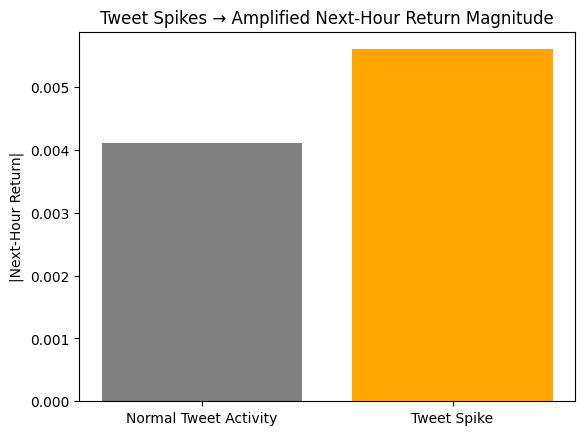

In [ ]:
# Mean |return| for spike vs normal
mean_spike = spike.mean()
mean_normal = normal.mean()

plt.bar(['Normal Tweet Activity', 'Tweet Spike'], [mean_normal, mean_spike], color=['gray', 'orange'])
plt.ylabel('|Next-Hour Return|')
plt.title('Tweet Spikes → Amplified Next-Hour Return Magnitude')
plt.show()

***Large increases in tweet activity significantly amplify next-hour return magnitude but do not influence return direction. Keeping log_tweet_count and tweet_spike.***

# *6. FGI Has Weak Hourly Predictive Power*

In [ ]:
corr, p_value = pearsonr(df1['FGI'], df1['next_return'])

print("Correlation (FGI vs hourly return):", corr)
print("p-value:", p_value)

Correlation (FGI vs hourly return): -6.944063605642328e-05
p-value: 0.9933681612160853


In [ ]:
df1['date_only'] = df1['date'].dt.date

intra_variation = df1.groupby('date_only')['FGI'].nunique()

print("Unique FGI values per day (should be 1):")
print(intra_variation.value_counts())

Unique FGI values per day (should be 1):
FGI
1    597
Name: count, dtype: int64


***Within a single day, FGI does not change — so using it for hourly predictions is pointless because it carries no new information across hours. REMOVE FGI.***

# *7. Extreme MACD values → increased |return|*

In [ ]:
# Compute 10th and 90th percentiles
low_thresh = df1['MACD'].quantile(0.1)
high_thresh = df1['MACD'].quantile(0.9)

# Flag extreme MACD values
df1['MACD_extreme_flag'] = np.where(
    (df1['MACD'] <= low_thresh) | (df1['MACD'] >= high_thresh),
    1,
    0
)

# Absolute next return
df1['abs_return'] = df1['next_return'].abs()

# Mean |return| for extreme and normal MACD
mean_extreme = df1[df1['MACD_extreme_flag'] == 1]['abs_return'].mean()
mean_normal = df1[df1['MACD_extreme_flag'] == 0]['abs_return'].mean()

print("Mean |return| for extreme MACD:", mean_extreme)
print("Mean |return| for normal MACD:", mean_normal)
print("Extreme > Normal?", mean_extreme > mean_normal)

Mean |return| for extreme MACD: 0.005476894584418226
Mean |return| for normal MACD: 0.003952433275585602
Extreme > Normal? True


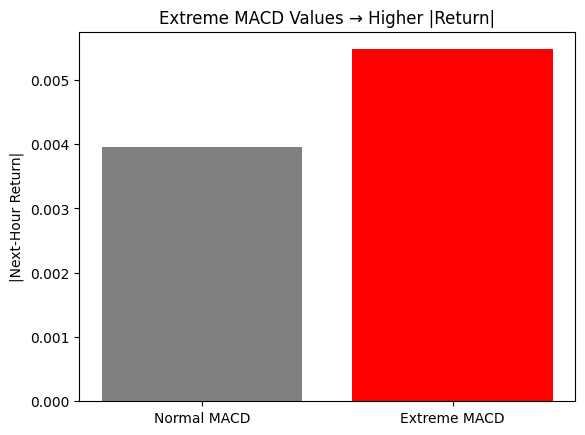

In [ ]:
# Data for plotting
labels = ['Normal MACD', 'Extreme MACD']
means = [mean_normal, mean_extreme]
colors = ['gray', 'red']

plt.bar(labels, means, color=colors)
plt.ylabel('|Next-Hour Return|')
plt.title('Extreme MACD Values → Higher |Return|')
plt.show()

In [ ]:
extreme_returns = df1[df1['MACD_extreme_flag'] == 1]['abs_return']
normal_returns = df1[df1['MACD_extreme_flag'] == 0]['abs_return']

stat, p_value = mannwhitneyu(extreme_returns, normal_returns, alternative='greater')
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 7.53307534076746e-53


***Extreme MACD values → |return| increase: True (statistically significant). Keep extreme MACD***

# Final Dataset Selection

In [ ]:
df1

,date,open,high,low,close,volume,asset,target,EMA_7,EMA_21,...,Up,EMA_reversion_signal,next_return,high_atr,abs_next_return,log_tweet_count,tweet_spike,date_only,MACD_extreme_flag,abs_return
0,2021-07-17 05:00:00,31410.68,31556.38,31406.10,31500.51,1108.13,BTC,31613.56,31480.865202,31624.380564,...,True,143.515362,0.003589,False,0.003589,2.397895,False,2021-07-17,0,0.003589
1,2021-07-17 06:00:00,31500.51,31614.95,31475.15,31613.56,813.76,BTC,31545.10,31514.038902,31623.396876,...,False,109.357975,-0.002166,False,0.002166,2.944439,False,2021-07-17,0,0.002166
2,2021-07-17 07:00:00,31613.56,31615.69,31495.93,31545.10,940.96,BTC,31730.45,31521.804176,31616.278979,...,True,94.474802,0.005876,False,0.005876,2.772589,False,2021-07-17,0,0.005876
3,2021-07-17 08:00:00,31545.10,31966.25,31383.23,31730.45,1320.14,BTC,31641.49,31573.965632,31626.658162,...,False,52.692530,-0.002804,False,0.002804,3.332205,False,2021-07-17,0,0.002804
4,2021-07-17 09:00:00,31730.45,31809.73,31632.94,31641.49,860.88,BTC,31323.53,31590.846724,31628.006511,...,False,37.159787,-0.010049,False,0.010049,6.126869,False,2021-07-17,0,0.010049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14325,2023-03-05 19:00:00,22435.69,22451.61,22387.08,22409.69,827.71,BTC,22414.95,22428.894031,22412.630587,...,True,-16.263444,0.000235,False,0.000235,6.553933,False,2023-03-05,0,0.000235
14326,2023-03-05 20:00:00,22409.69,22424.07,22403.98,22414.95,395.82,BTC,22488.75,22425.408023,22412.841442,...,True,-12.566581,0.003292,False,0.003292,6.492240,False,2023-03-05,0,0.003292
14327,2023-03-05 21:00:00,22414.95,22536.32,22358.69,22488.75,2366.50,BTC,22436.93,22441.243517,22419.742220,...,False,-21.501297,-0.002304,False,0.002304,6.403574,False,2023-03-05,0,0.002304
14328,2023-03-05 22:00:00,22488.75,22490.74,22397.85,22436.93,939.00,BTC,22434.09,22440.165138,22421.304746,...,False,-18.860392,-0.000127,False,0.000127,6.263398,False,2023-03-05,0,0.000127


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14330 entries, 0 to 14329
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  14330 non-null  datetime64[ns]
 1   open                  14330 non-null  float64       
 2   high                  14330 non-null  float64       
 3   low                   14330 non-null  float64       
 4   close                 14330 non-null  float64       
 5   volume                14330 non-null  float64       
 6   asset                 14330 non-null  object        
 7   target                14330 non-null  float64       
 8   EMA_7                 14330 non-null  float64       
 9   EMA_21                14330 non-null  float64       
 10  RSI_14                14330 non-null  float64       
 11  MACD                  14330 non-null  float64       
 12  BB_Width              14330 non-null  float64       
 13  ATR_14          

In [ ]:
final_df = df1.drop(['FGI', 'tweet_count', 'EMA_7', 'RSI_14',
                     'EMA_21', 'EMA_diff', 'Up', 'abs_return',
                     'date_only', 'abs_next_return', 'next_return'], axis=1)

In [ ]:
final_df.isna().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0
asset,0
target,0
MACD,0
BB_Width,0


In [ ]:
train_size = int(len(final_df) * 0.8)

train_df = final_df.iloc[:train_size].copy()
val_df   = final_df.iloc[train_size:].copy()

print(len(train_df), len(val_df))

11464 2866


In [ ]:
train_original = train_df.copy()
val_original = val_df.copy()

In [ ]:
train_original.info(), val_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11464 entries, 0 to 11463
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  11464 non-null  datetime64[ns]
 1   open                  11464 non-null  float64       
 2   high                  11464 non-null  float64       
 3   low                   11464 non-null  float64       
 4   close                 11464 non-null  float64       
 5   volume                11464 non-null  float64       
 6   asset                 11464 non-null  object        
 7   target                11464 non-null  float64       
 8   MACD                  11464 non-null  float64       
 9   BB_Width              11464 non-null  float64       
 10  ATR_14                11464 non-null  float64       
 11  vader_score           11464 non-null  float64       
 12  roberta_score         11464 non-null  float64       
 13  sentiment_missin

(None, None)

In [ ]:
for i in (train_df, val_df, train_original, val_original):
  i['year'] = i.date.dt.year
  i['month'] = i.date.dt.month
  i['day'] = i.date.dt.day
  i['hour'] = i.date.dt.hour

In [ ]:
train_df

,date,open,high,low,close,volume,asset,target,MACD,BB_Width,...,sentiment_missing,EMA_reversion_signal,high_atr,log_tweet_count,tweet_spike,MACD_extreme_flag,year,month,day,hour
0,2021-07-17 05:00:00,31410.68,31556.38,31406.10,31500.51,1108.13,BTC,31613.56,-113.205712,0.018995,...,0,143.515362,False,2.397895,False,0,2021,7,17,5
1,2021-07-17 06:00:00,31500.51,31614.95,31475.15,31613.56,813.76,BTC,31545.10,-99.528202,0.018335,...,0,109.357975,False,2.944439,False,0,2021,7,17,6
2,2021-07-17 07:00:00,31613.56,31615.69,31495.93,31545.10,940.96,BTC,31730.45,-93.139176,0.016328,...,0,94.474802,False,2.772589,False,0,2021,7,17,7
3,2021-07-17 08:00:00,31545.10,31966.25,31383.23,31730.45,1320.14,BTC,31641.49,-72.286359,0.016332,...,0,52.692530,False,3.332205,False,0,2021,7,17,8
4,2021-07-17 09:00:00,31730.45,31809.73,31632.94,31641.49,860.88,BTC,31323.53,-62.221430,0.016317,...,0,37.159787,False,6.126869,False,0,2021,7,17,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11459,2022-11-06 10:00:00,21239.34,21279.66,21237.17,21266.05,509.39,BTC,21253.49,8.627903,0.005534,...,1,8.870402,False,0.000000,False,0,2022,11,6,10
11460,2022-11-06 11:00:00,21266.05,21275.19,21181.02,21253.49,1043.23,BTC,21228.61,8.873102,0.005497,...,1,5.300267,False,0.000000,False,0,2022,11,6,11
11461,2022-11-06 12:00:00,21253.49,21269.22,21219.45,21228.61,807.60,BTC,21217.30,6.979361,0.005397,...,1,6.703806,False,0.000000,False,0,2022,11,6,12
11462,2022-11-06 13:00:00,21228.61,21246.54,21207.75,21217.30,904.96,BTC,21225.52,4.513902,0.005302,...,1,9.307723,False,0.000000,False,0,2022,11,6,13


In [ ]:
train_df['day_of_week'] = train_df['date'].dt.dayofweek
val_df['day_of_week'] = val_df['date'].dt.dayofweek

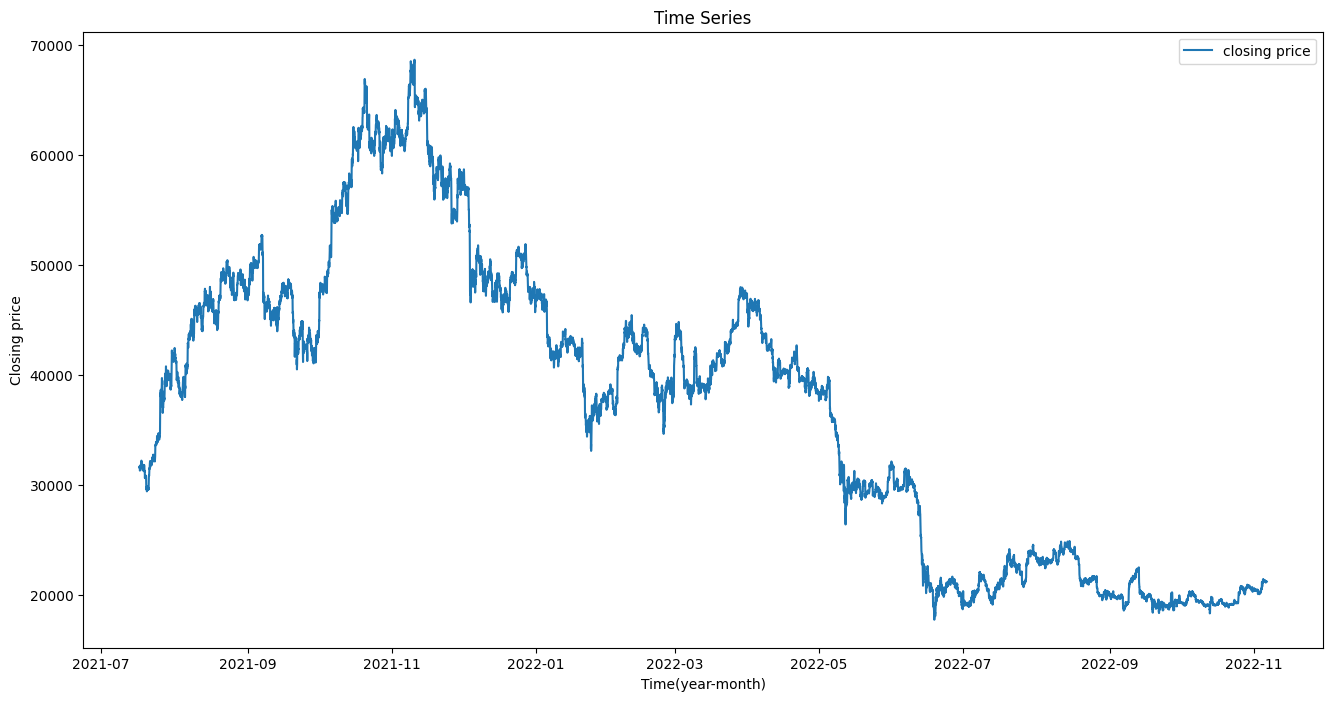

In [ ]:
train_df.index = train_df['date']
target = train_df['target']
plt.figure(figsize=(16, 8))
plt.plot(target, label='closing price')
plt.title('Time Series')
plt.xlabel("Time(year-month)")
plt.ylabel("Closing price")
plt.legend(loc='best')
plt.show()

In [ ]:
train_df.Timestamp = pd.to_datetime(train_df.date, format='%d-%m-%Y %H:%M')
val_df.Timestamp = pd.to_datetime(val_df.date, format='%d-%m-%Y %H:%M')
train_df.index = train_df.Timestamp
val_df.index = val_df.Timestamp
# hourly time series
hourly = train_df['target'].resample('H').mean()
four_h  = train_df['target'].resample('4H').mean()  # 4-hour
eight_h = train_df['target'].resample('8H').mean()  # 8-hour
twelve_h = train_df['target'].resample('12H').mean() # 12-hour
# daily time series
daily = train_df['target'].resample('D').mean()
# weekly time series
weekly = train_df['target'].resample('W').mean()
# monthly time series
monthly = train_df['target'].resample('M').mean()

/tmp/ipython-input-753106564.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  train_df.Timestamp = pd.to_datetime(train_df.date, format='%d-%m-%Y %H:%M')
/tmp/ipython-input-753106564.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  val_df.Timestamp = pd.to_datetime(val_df.date, format='%d-%m-%Y %H:%M')
/tmp/ipython-input-753106564.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = train_df['target'].resample('H').mean()
/tmp/ipython-input-753106564.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  four_h  = train_df['target'].resample('4H').mean()  # 4-hour
/tmp/ipython-input-753106564.py:8: FutureWarning: 'H' is deprecated and 

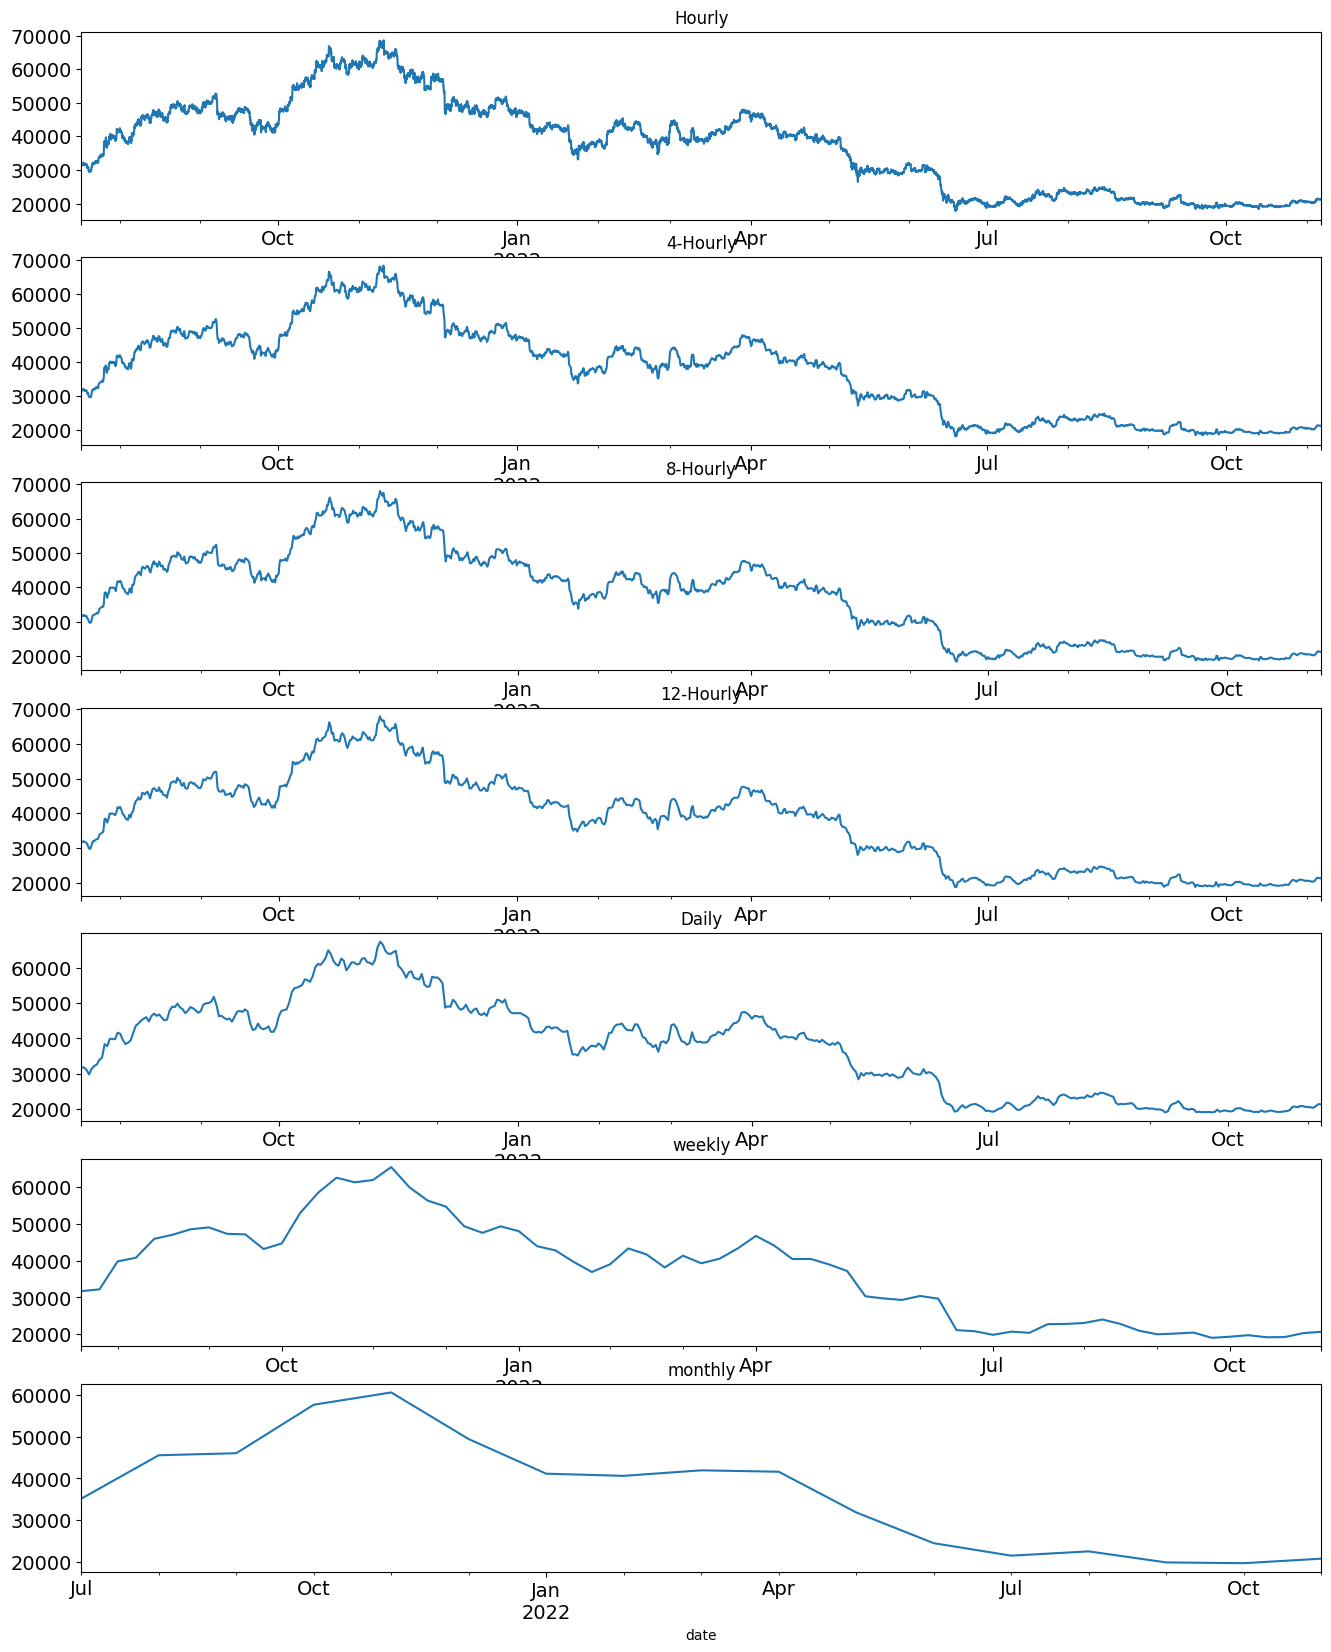

In [ ]:
fig, ax = plt.subplots(7, 1)
hourly.plot(figsize=(16, 20), title='Hourly', fontsize=14, ax=ax[0])
four_h.plot(figsize=(16, 20), title='4-Hourly', fontsize=14, ax=ax[1])
eight_h.plot(figsize=(16, 20), title='8-Hourly', fontsize=14, ax=ax[2])
twelve_h.plot(figsize=(16, 20), title='12-Hourly', fontsize=14, ax=ax[3])
daily.plot(figsize=(16, 20), title='Daily', fontsize=14, ax=ax[4])
weekly.plot(figsize=(16, 20), title='weekly', fontsize=14, ax=ax[5])
monthly.plot(figsize=(16, 20), title='monthly', fontsize=14, ax=ax[6])
plt.show()

In [ ]:
train_df.tail(1)

,date,open,high,low,close,volume,asset,target,MACD,BB_Width,...,EMA_reversion_signal,high_atr,log_tweet_count,tweet_spike,MACD_extreme_flag,year,month,day,hour,day_of_week
date,,,,,,,,,,,,,,,,,,,,,
2022-11-06 14:00:00,2022-11-06 14:00:00,21217.3,21257.58,21191.46,21225.52,941.09,BTC,21244.65,3.186561,0.005278,...,9.563854,False,0.0,False,0,2022,11,6,14,6


In [ ]:
val_df.head(1)

,date,open,high,low,close,volume,asset,target,MACD,BB_Width,...,EMA_reversion_signal,high_atr,log_tweet_count,tweet_spike,MACD_extreme_flag,year,month,day,hour,day_of_week
date,,,,,,,,,,,,,,,,,,,,,
2022-11-06 15:00:00,2022-11-06 15:00:00,21225.52,21285.54,21224.77,21244.65,1315.17,BTC,21259.62,3.636347,0.004981,...,6.47772,False,0.0,False,0,2022,11,6,15,6


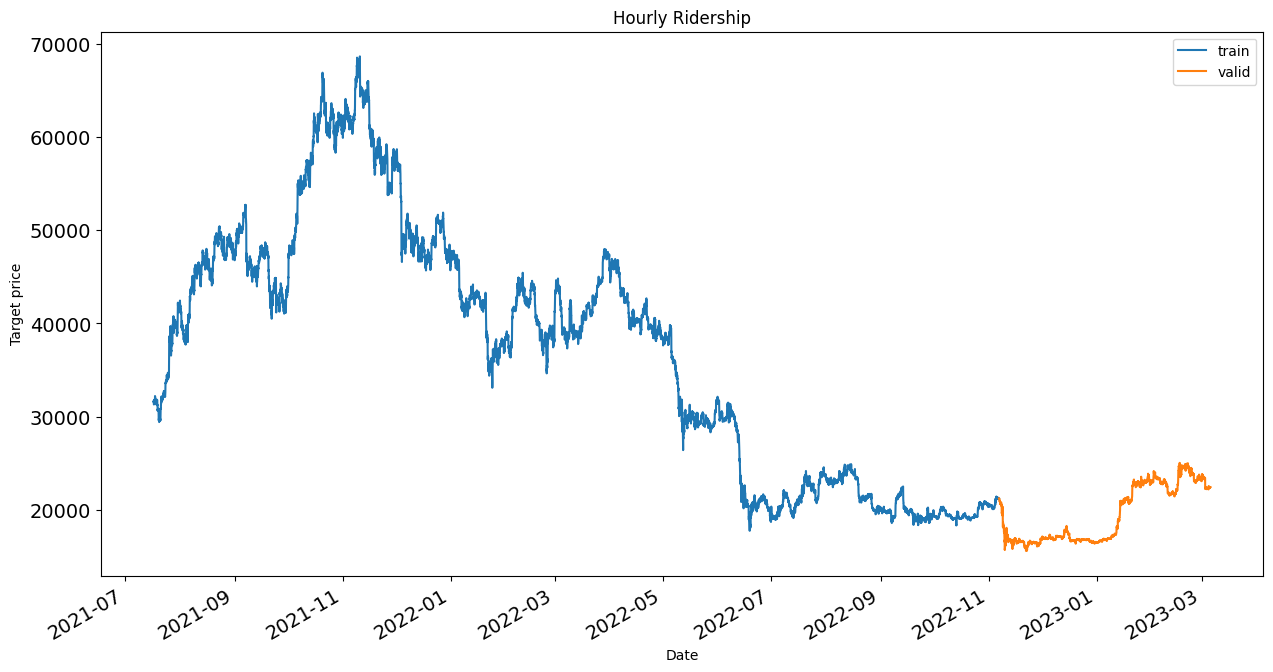

In [ ]:
train_df.target.plot(figsize=(15, 8), title='Hourly Ridership', fontsize=14, label='train')
val_df.target.plot(figsize=(15, 8), title='Hourly Ridership', fontsize=14, label='valid')
plt.xlabel('Date')
plt.ylabel('Target price')
plt.legend(loc='best')
plt.show()

In [ ]:
train_df.to_csv('train.csv')
val_df.to_csv('valid.csv')